In [6]:
import os
os.chdir('/workspaces/energy-prediction/')  # Change le répertoire vers la racine
print(os.getcwd())  # Vérif

/workspaces/energy-prediction


In [7]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib

# 1. Chargement des données
df_conso = pd.read_csv("./data/prepared/df_daily_conso.csv", parse_dates=["Date"])
df_meteo = pd.read_csv("./data/prepared/meteo_clean.csv", parse_dates=["date"])



# 2. Agrégation météo à la journée (moyenne par jour)
df_meteo["Date"] = df_meteo["date"].dt.date
df_meteo["Date"] = pd.to_datetime(df_meteo["Date"])  # Assure qu'on a datetime64[ns]

df_meteo_daily = df_meteo.groupby("Date")[[
    'temperature', 'humidity', 'pressure_sea_level',
    'wind_direction', 'wind_speed', 'min_soil_temp'
]].mean().reset_index()

# 3. Fusion des deux jeux de données
df = pd.merge(df_conso, df_meteo_daily, on="Date", how="inner")


In [8]:

# 4. Sélection des features et cible
features = [
    'temperature', 'humidity', 'pressure_sea_level',
    'wind_direction', 'wind_speed', 'min_soil_temp',
    'month', 'day_of_week', 'is_weekend'
]
target = 'ConsommationTotale'

X = df[features]
y = df[target]

# 5. Normalisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 6. Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

RMSE : 399,259.61 kWh

Poids des variables dans la prédiction :
              Feature    Coefficient
0         temperature -809370.859542
8          is_weekend -162018.499091
3      wind_direction  -75035.224871
1            humidity  -32947.294992
4          wind_speed   12470.752882
7         day_of_week    9814.687958
6               month   -6891.250683
5       min_soil_temp   -5907.334217
2  pressure_sea_level   -5342.749213


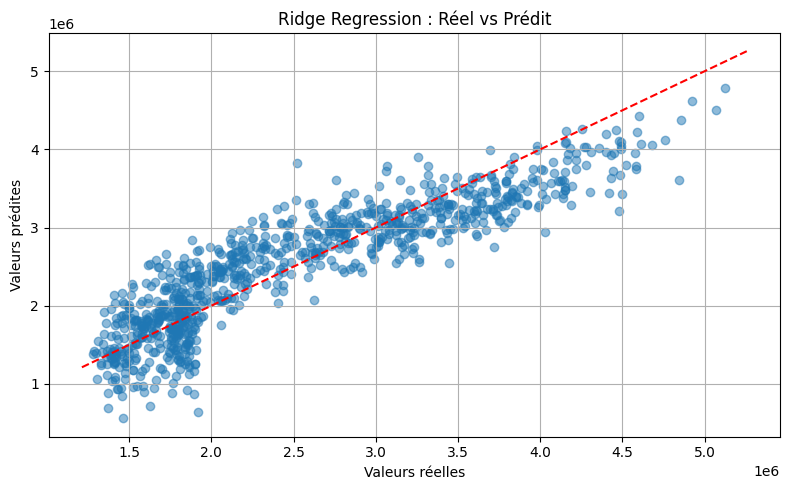

['features.pkl']

In [ ]:


# 7. Entraînement du modèle Ridge
ridge = Ridge(alpha=1.0)  # tu peux ajuster alpha
ridge.fit(X_train, y_train)

# 8. Prédictions et évaluation
y_pred = ridge.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : {rmse:,.2f} kWh")

# 9. (Optionnel) Analyse des coefficients
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nPoids des variables dans la prédiction :")
print(coef_df)

# 10. (Optionnel) Visualisation des performances
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Ridge Regression : Réel vs Prédit")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.grid(True)
plt.tight_layout()
plt.show()

# 11. (Optionnel) Sauvegarde du modèle
joblib.dump(ridge, "model.pkl") 
# joblib.dump(scaler, "scaler.pkl")
# Sauvegarde des noms de features (important pour plus tard)
joblib.dump(features, 'features.pkl')
